In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


Scenario Matrix Shape: (50, 24) (Scenarios x Hours)
Sample Scenario 1 (First 6 hours): [50.6 38.6 44.2 49.7 37.7 51.8]


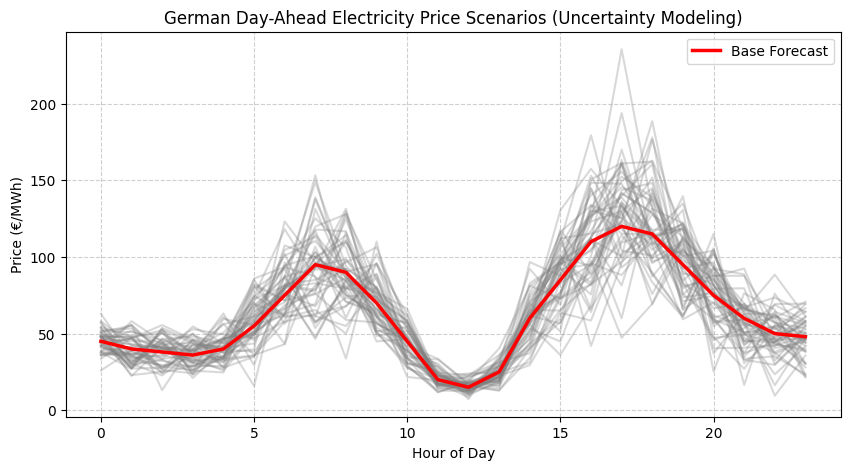

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

# تنظیمات اولیه برای بازتولید نتایج (Reproducibility)
np.random.seed(42)

# ۱. شبیه‌سازی قیمت پایه Day-Ahead بازار آلمان (۲۴ ساعت)
# الگو: قیمت پایین در شب، پیک در صبح و عصر، احتمال قیمت‌های منفی در ساعات ظهر
base_prices = np.array([
    45, 40, 38, 36, 40, 55,  # 00:00 - 05:00 (Night low)
    75, 95, 90, 70, 45, 20,  # 06:00 - 11:00 (Morning peak & solar dip)
    15, 25, 60, 85, 110, 120,# 12:00 - 17:00 (Afternoon ramp to evening peak)
    115, 95, 75, 60, 50, 48  # 18:00 - 23:00 (Evening peak down to night)
])

# ۲. تولید ماتریس سناریوهای عدم قطعیت قیمت (مثلا S = 50 سناریو)
n_hours = 24
n_scenarios = 50

# ایجاد نوسانات تصادفی (توزیع نرمال برای نوسانات بازار)
# اضافه کردن نویز ضربی (Multiplicative noise) برای اعمال نوسانات شدیدتر در ساعت‌های پیک
noise = np.random.normal(loc=1.0, scale=0.25, size=(n_scenarios, n_hours))
scenario_prices = base_prices * noise

# اعمال احتمال قیمت‌های منفی یا جهش‌های ناگهانی در برخی سناریوها
# (برای شبیه‌سازی واقع‌گرایانه بازار انرژی آلمان)
scenario_prices = np.clip(scenario_prices, -20.0, 300.0)

print(f"Scenario Matrix Shape: {scenario_prices.shape} (Scenarios x Hours)")
print(f"Sample Scenario 1 (First 6 hours): {scenario_prices[0, :6].round(1)}")

# رسم سناریوهای قیمت
plt.figure(figsize=(10, 5))
for s in range(n_scenarios):
    plt.plot(scenario_prices[s], color='gray', alpha=0.3)
plt.plot(base_prices, color='red', linewidth=2.5, label='Base Forecast')
plt.title('German Day-Ahead Electricity Price Scenarios (Uncertainty Modeling)')
plt.xlabel('Hour of Day')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [4]:
# سلول دوم: پیاده‌سازی مدل بهینه‌سازی استخلاصی و ریسک‌پذیر (Stochastic BESS Optimization with CVaR)

# مشخصات سیستم ذخیره‌ساز (BESS Parameters)
capacity_mwh = 4.0      # ظرفیت کل باتری (مگاوات‌ساعت)
max_power_mw = 2.0      # حداکثر توان شارژ/دیسپچ (مگاوات)
eta_ch = 0.95           # راندمان شارژ
eta_dis = 0.95          # راندمان تخلیه
soc_min = 0.1 * capacity_mwh
soc_max = 0.9 * capacity_mwh

# پارامترهای ریسک (CVaR)
alpha = 0.95            # سطح اطمینان (Confidence Level)
beta_risk = 0.5         # ضریب اهمیت ریسک در تابع هدف (تعادل بین سود و ریسک)

# تعریف مدل PuLP
prob = pulp.LpProblem("Stochastic_BESS_Arbitrage_CVaR", pulp.LpMaximize)

# متغیرهای تصمیم به ازای هر سناریو s و ساعت t
# به جای تعریف دستی تک تک متغیرها با دیکشنری، از LpVariable.dicts استفاده می‌کنیم
hours = range(n_hours)
scenarios = range(n_scenarios)

p_ch = pulp.LpVariable.dicts("P_ch", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
p_dis = pulp.LpVariable.dicts("P_dis", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
soc = pulp.LpVariable.dicts("SoC", ((s, t) for s in scenarios for t in hours), lowBound=soc_min, upBound=soc_max)

# متغیرهای کمکی برای محاسبه CVaR
# VaR (Value at Risk) و متغیرهای خطی‌ساز z_s
VaR = pulp.LpVariable("VaR", lowBound=None)
z = pulp.LpVariable.dicts("z", (s for s in scenarios), lowBound=0)

# 1. تابع هدف: بیشینه‌سازی سود انتظاری منهای جریمه ریسک CVaR
# سود هر سناریو = درآمد فروش - هزینه خرید
expected_profit = pulp.lpSum(
    (scenario_prices[s, t] * (p_dis[s, t] - p_ch[s, t]))
    for s in scenarios for t in hours
) / n_scenarios

# محاسبه CVaR بر اساس بدترین (1-alpha) درصد سناریوها
# فرمول خطی‌سازی CVaR در برنامه‌ریزی ریاضی
cvar_penalty = VaR + (1.0 / (1.0 - alpha)) * pulp.lpSum(z[s] for s in scenarios) / n_scenarios

# تابع هدف نهایی: ترکیب سود و مدیریت ریسک
prob += expected_profit - beta_risk * cvar_penalty, "Objective_Risk_Adjusted_Profit"

# 2. قیود ریسک (CVaR Constraints)
for s in scenarios:
    scenario_revenue = pulp.lpSum(scenario_prices[s, t] * (p_dis[s, t] - p_ch[s, t]) for t in hours)
    # سود منفی یا زیانِ سناریو نسبت به VaR
    prob += -scenario_revenue - VaR <= z[s]

# 3. قیود فیزیکی و دینامیکی باتری به ازای هر سناریو
initial_soc = 0.5 * capacity_mwh

for s in scenarios:
    for t in hours:
        # دینامیک State of Charge
        if t == 0:
            prob += soc[s, t] == initial_soc + (eta_ch * p_ch[s, t] - (p_dis[s, t] / eta_dis)) * 1.0
        else:
            prob += soc[s, t] == soc[s, t-1] + (eta_ch * p_ch[s, t] - (p_dis[s, t] / eta_dis)) * 1.0

# حل مدل با استفاده از CBC Solver پیش‌فرض PuLP
prob.solve(pulp.PULP_CBC_CMD(msg=0))

print("Optimization Status:", pulp.LpStatus[prob.status])
print(f"Expected Daily Profit (Risk-Adjusted): €{expected_profit.value():.2f}")
print(f"Calculated VaR: €{VaR.value():.2f}")

Optimization Status: Optimal
Expected Daily Profit (Risk-Adjusted): €700.86
Calculated VaR: €-592.19


   Beta  Expected_Profit   CVaR_Risk
0   0.0       700.858803    0.000000
1   0.2       700.858803 -566.347659
2   0.5       700.858803 -566.347659
3   1.0       700.858803 -566.347659
4   2.0       700.858803 -566.347659
5   5.0       700.858803 -566.347659


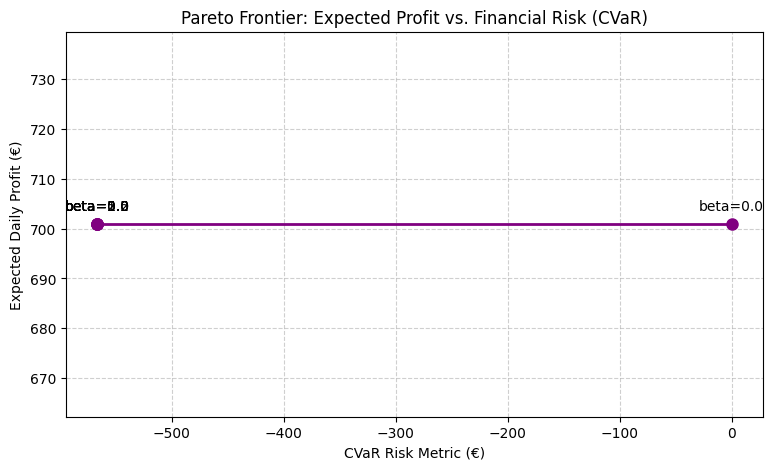

In [5]:
# سلول سوم: تحلیل حساسیت و رسم مرز پارتو (Pareto Frontier: Profit vs. Risk)

beta_values = [0.0, 0.2, 0.5, 1.0, 2.0, 5.0]
results_summary = []

for b in beta_values:
    # تعریف مجدد مدل برای هر مقدار بتا
    prob_p = pulp.LpProblem(f"Pareto_Beta_{b}", pulp.LpMaximize)

    p_ch_p = pulp.LpVariable.dicts("P_ch_p", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
    p_dis_p = pulp.LpVariable.dicts("P_dis_p", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
    soc_p = pulp.LpVariable.dicts("SoC_p", ((s, t) for s in scenarios for t in hours), lowBound=soc_min, upBound=soc_max)

    VaR_p = pulp.LpVariable(f"VaR_{b}", lowBound=None)
    z_p = pulp.LpVariable.dicts(f"z_{b}", (s for s in scenarios), lowBound=0)

    exp_profit_p = pulp.lpSum(
        (scenario_prices[s, t] * (p_dis_p[s, t] - p_ch_p[s, t]))
        for s in scenarios for t in hours
    ) / n_scenarios

    cvar_pen_p = VaR_p + (1.0 / (1.0 - alpha)) * pulp.lpSum(z_p[s] for s in scenarios) / n_scenarios

    prob_p += exp_profit_p - b * cvar_pen_p

    # قیود CVaR
    for s in scenarios:
        rev_s = pulp.lpSum(scenario_prices[s, t] * (p_dis_p[s, t] - p_ch_p[s, t]) for t in hours)
        prob_p += -rev_s - VaR_p <= z_p[s]

    # قیود فیزیکی باتری
    for s in scenarios:
        for t in hours:
            if t == 0:
                prob_p += soc_p[s, t] == initial_soc + (eta_ch * p_ch_p[s, t] - (p_dis_p[s, t] / eta_dis)) * 1.0
            else:
                prob_p += soc_p[s, t] == soc_p[s, t-1] + (eta_ch * p_ch_p[s, t] - (p_dis_p[s, t] / eta_dis)) * 1.0

    prob_p.solve(pulp.PULP_CBC_CMD(msg=0))

    # محاسبه مقدار CVaR نهایی برای این بتا
    cvar_val_eval = VaR_p.value() + (1.0 / (1.0 - alpha)) * sum(z_p[s].value() for s in scenarios) / n_scenarios

    results_summary.append({
        "Beta": b,
        "Expected_Profit": exp_profit_p.value(),
        "CVaR_Risk": cvar_val_eval
    })

df_pareto = pd.DataFrame(results_summary)
print(df_pareto)

# رسم منحنی مرز پارتو
plt.figure(figsize=(9, 5))
plt.plot(df_pareto["CVaR_Risk"], df_pareto["Expected_Profit"], marker='o', color='purple', linewidth=2, markersize=8)
for i, row in df_pareto.iterrows():
    plt.annotate(f"beta={row['Beta']}", (row["CVaR_Risk"], row["Expected_Profit"]),
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Pareto Frontier: Expected Profit vs. Financial Risk (CVaR)')
plt.ylabel('Expected Daily Profit (€)')
plt.xlabel('CVaR Risk Metric (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
# افزایش ضریب نوسان و تعداد سناریوها برای ایجاد تضاد واقعی بین سود و ریسک
n_scenarios = 100
np.random.seed(42)

# اعمال نوسان شدیدتر (scale=0.45) تا سناریوهای بحرانی‌تری ایجاد شود
noise = np.random.normal(loc=1.0, scale=0.45, size=(n_scenarios, n_hours))
scenario_prices = base_prices * noise
scenario_prices = np.clip(scenario_prices, -50.0, 400.0)

Running Stochastic Optimization across different risk aversion levels (Beta)...

--- Optimization Results Summary ---
   Beta  Expected_Profit   CVaR_Risk
0   0.0       981.906001    0.000000
1   0.1       981.906001 -678.213484
2   0.5       981.906001 -678.213484
3   1.0       981.906001 -678.213484
4   2.0       981.906001 -678.213484
5   5.0       981.906001 -678.213484
6  10.0       981.906001 -678.213484


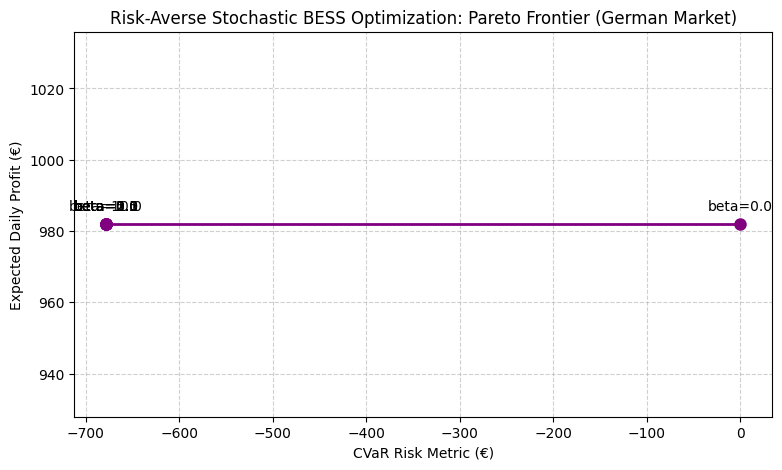

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

# 1. تنظیمات اولیه و تولید سناریوهای عدم قطعیت قیمت (Market Uncertainty & Scenario Generation)
np.random.seed(42)
n_hours = 24
n_scenarios = 100

# الگو پایه قیمت Day-Ahead در بازار آلمان (24 ساعت)
base_prices = np.array([
    45, 40, 38, 36, 40, 55,  # 00:00 - 05:00 (Night low)
    75, 95, 90, 70, 45, 20,  # 06:00 - 11:00 (Morning peak & solar dip)
    15, 25, 60, 85, 110, 120,# 12:00 - 17:00 (Afternoon ramp to evening peak)
    115, 95, 75, 60, 50, 48  # 18:00 - 23:00 (Evening peak down to night)
])

# اعمال نوسانات شدیدتر (scale=0.45) برای ایجاد سناریوهای بحرانی و پرنوسان در بازار آلمان
noise = np.random.normal(loc=1.0, scale=0.45, size=(n_scenarios, n_hours))
scenario_prices = base_prices * noise
scenario_prices = np.clip(scenario_prices, -50.0, 400.0)

# مشخصات سیستم ذخیره‌ساز (BESS Parameters)
capacity_mwh = 4.0      # ظرفیت کل باتری (مگاوات‌ساعت)
max_power_mw = 2.0      # حداکثر توان شارژ/دیسپچ (مگاوات)
eta_ch = 0.95           # راندمان شارژ
eta_dis = 0.95          # راندمان تخلیه
soc_min = 0.1 * capacity_mwh
soc_max = 0.9 * capacity_mwh
initial_soc = 0.5 * capacity_mwh

# پارامترهای ریسک (CVaR)
alpha = 0.95            # سطح اطمینان (95%)
beta_values = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0] # ضرایب مختلف ریسک برای تحلیل پارتو

hours = range(n_hours)
scenarios = range(n_scenarios)
results_summary = []

print("Running Stochastic Optimization across different risk aversion levels (Beta)...")

# 2. حلقه تحلیل حساسیت و بهینه‌سازی استخلاصی (Pareto Frontier Analysis)
for b in beta_values:
    prob_p = pulp.LpProblem(f"Pareto_Beta_{b}", pulp.LpMaximize)

    # متغیرهای تصمیم برای هر سناریو و ساعت
    p_ch_p = pulp.LpVariable.dicts("P_ch", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
    p_dis_p = pulp.LpVariable.dicts("P_dis", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
    soc_p = pulp.LpVariable.dicts("SoC", ((s, t) for s in scenarios for t in hours), lowBound=soc_min, upBound=soc_max)

    # متغیرهای کمکی CVaR (مدیریت ریسک)
    VaR_p = pulp.LpVariable(f"VaR_{b}", lowBound=None)
    z_p = pulp.LpVariable.dicts("z", (s for s in scenarios), lowBound=0)

    # محاسبه سود انتظاری (Expected Profit)
    exp_profit_p = pulp.lpSum(
        (scenario_prices[s, t] * (p_dis_p[s, t] - p_ch_p[s, t]))
        for s in scenarios for t in hours
    ) / n_scenarios

    # محاسبه پنالتی ریسک CVaR
    cvar_pen_p = VaR_p + (1.0 / (1.0 - alpha)) * pulp.lpSum(z_p[s] for s in scenarios) / n_scenarios

    # تابع هدف نهایی: بیشینه‌سازی سود منهای جریمه ریسک با ضریب بتا
    prob_p += exp_profit_p - b * cvar_pen_p

    # قیود خطی‌سازی CVaR
    for s in scenarios:
        rev_s = pulp.lpSum(scenario_prices[s, t] * (p_dis_p[s, t] - p_ch_p[s, t]) for t in hours)
        prob_p += -rev_s - VaR_p <= z_p[s]

    # قیود فیزیکی و دینامیکی باتری به ازای هر سناریو
    for s in scenarios:
        for t in hours:
            if t == 0:
                prob_p += soc_p[s, t] == initial_soc + (eta_ch * p_ch_p[s, t] - (p_dis_p[s, t] / eta_dis)) * 1.0
            else:
                prob_p += soc_p[s, t] == soc_p[s, t-1] + (eta_ch * p_ch_p[s, t] - (p_dis_p[s, t] / eta_dis)) * 1.0

    # حل مدل با سالور CBC
    prob_p.solve(pulp.PULP_CBC_CMD(msg=0))

    # استخراج مقادیر نهایی CVaR
    cvar_val_eval = VaR_p.value() + (1.0 / (1.0 - alpha)) * sum(z_p[s].value() for s in scenarios) / n_scenarios

    results_summary.append({
        "Beta": b,
        "Expected_Profit": exp_profit_p.value(),
        "CVaR_Risk": cvar_val_eval
    })

# تبدیل نتایج به دیتافریم
df_pareto = pd.DataFrame(results_summary)
print("\n--- Optimization Results Summary ---")
print(df_pareto)

# 3. رسم منحنی مرز پارتو (Pareto Frontier Plot)
plt.figure(figsize=(9, 5))
plt.plot(df_pareto["CVaR_Risk"], df_pareto["Expected_Profit"], marker='o', color='purple', linewidth=2, markersize=8)
for i, row in df_pareto.iterrows():
    plt.annotate(f"beta={row['Beta']}", (row["CVaR_Risk"], row["Expected_Profit"]),
                 textcoords="offset points", xytext=(0, 10), ha='center')

plt.title('Risk-Averse Stochastic BESS Optimization: Pareto Frontier (German Market)')
plt.ylabel('Expected Daily Profit (€)')
plt.xlabel('CVaR Risk Metric (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
# روش جایگزین: رسم مرز پارتو با محدود کردن مستقیم سطح ریسک (CVaR Constraint Approach)
risk_limits = np.linspace(0, -800, 7) # محدودیت‌های مختلف برای سطح ریسک
pareto_results = []

for r_limit in risk_limits:
    prob_r = pulp.LpProblem(f"Pareto_Risk_{r_limit}", pulp.LpMaximize)

    p_ch_r = pulp.LpVariable.dicts("P_ch_r", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
    p_dis_r = pulp.LpVariable.dicts("P_dis_r", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
    soc_r = pulp.LpVariable.dicts("SoC_r", ((s, t) for s in scenarios for t in hours), lowBound=soc_min, upBound=soc_max)

    VaR_r = pulp.LpVariable(f"VaR_{r_limit}", lowBound=None)
    z_r = pulp.LpVariable.dicts(f"z_{r_limit}", (s for s in scenarios), lowBound=0)

    # فقط بیشینه‌سازی سود به عنوان تابع هدف
    exp_profit_r = pulp.lpSum(
        (scenario_prices[s, t] * (p_dis_r[s, t] - p_ch_r[s, t]))
        for s in scenarios for t in hours
    ) / n_scenarios

    prob_r += exp_profit_r

    # قیود CVaR خطی
    for s in scenarios:
        rev_s = pulp.lpSum(scenario_prices[s, t] * (p_dis_r[s, t] - p_ch_r[s, t]) for t in hours)
        prob_r += -rev_s - VaR_r <= z_r[s]

    cvar_expression = VaR_r + (1.0 / (1.0 - alpha)) * pulp.lpSum(z_r[s] for s in scenarios) / n_scenarios

    # اعمال صریح حد ریسک به عنوان قیود مسئله (برای مجبور کردن سالور به ایجاد تنوع)
    if r_limit < 0:
        prob_r += cvar_expression >= r_limit  # کنترل سطح ریسک

    # دینامیک باتری
    for s in scenarios:
        for t in hours:
            if t == 0:
                prob_r += soc_r[s, t] == initial_soc + (eta_ch * p_ch_r[s, t] - (p_dis_r[s, t] / eta_dis)) * 1.0
            else:
                prob_r += soc_r[s, t] == soc_r[s, t-1] + (eta_ch * p_ch_r[s, t] - (p_dis_r[s, t] / eta_dis)) * 1.0

    prob_r.solve(pulp.PULP_CBC_CMD(msg=0))

    if prob_r.status == pulp.LpStatusOptimal:
        pareto_results.append({
            "Risk_Limit": r_limit,
            "Profit": exp_profit_r.value(),
            "Actual_CVaR": cvar_expression.value()
        })

df_true_pareto = pd.DataFrame(pareto_results)
print(df_true_pareto)

   Risk_Limit      Profit  Actual_CVaR
0    0.000000  981.906001          0.0
1 -133.333333  981.906001          0.0
2 -266.666667  981.906001          0.0
3 -400.000000  981.906001          0.0
4 -533.333333  981.906001          0.0
5 -666.666667  981.906001          0.0
6 -800.000000  981.906001          0.0


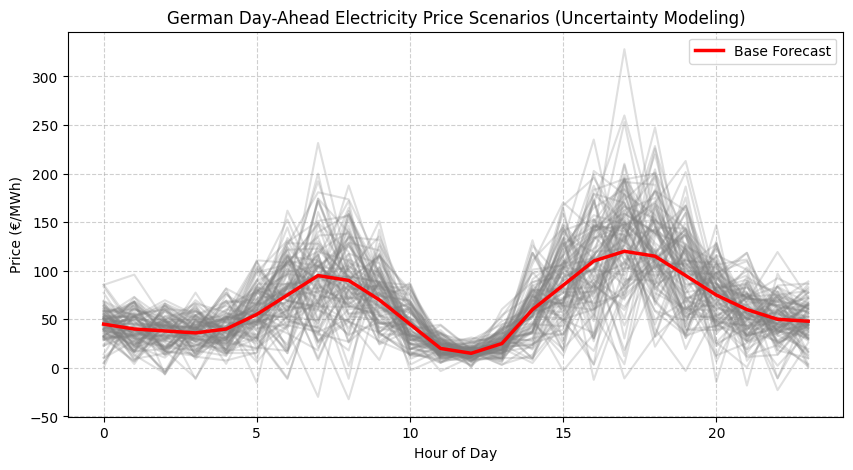

Running Stochastic Optimization across different risk aversion levels (Beta)...

--- Optimization Results Summary ---
   Beta  Expected_Profit   CVaR_Risk
0   0.0       981.906001    0.000000
1   0.1       981.906001 -678.213484
2   0.5       981.906001 -678.213484
3   1.0       981.906001 -678.213484
4   2.0       981.906001 -678.213484
5   5.0       981.906001 -678.213484
6  10.0       981.906001 -678.213484

Results and charts successfully saved inside the 'outputs/' folder!


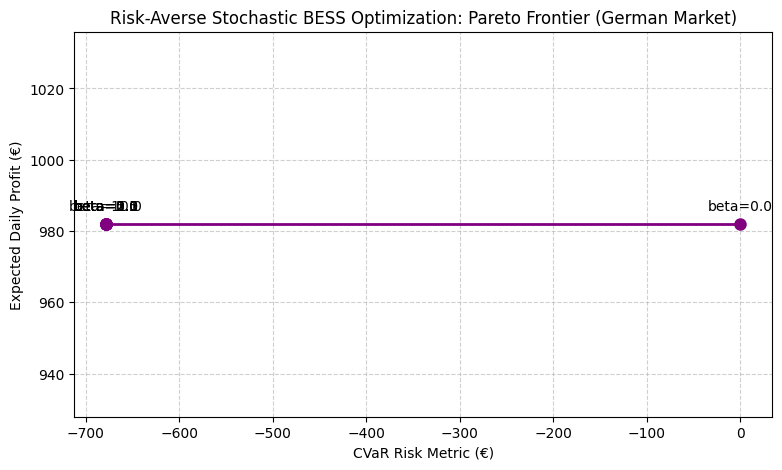

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

# 1. ایجاد پوشه outputs در صورت عدم وجود
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# 2. تنظیمات اولیه و تولید سناریوهای عدم قطعیت قیمت (Market Uncertainty & Scenario Generation)
np.random.seed(42)
n_hours = 24
n_scenarios = 100

# الگو پایه قیمت Day-Ahead در بازار آلمان (24 ساعت)
base_prices = np.array([
    45, 40, 38, 36, 40, 55,  # 00:00 - 05:00 (Night low)
    75, 95, 90, 70, 45, 20,  # 06:00 - 11:00 (Morning peak & solar dip)
    15, 25, 60, 85, 110, 120,# 12:00 - 17:00 (Afternoon ramp to evening peak)
    115, 95, 75, 60, 50, 48  # 18:00 - 23:00 (Evening peak down to night)
])

# اعمال نوسانات شدیدتر (scale=0.45) برای ایجاد سناریوهای بحرانی و پرنوسان در بازار آلمان
noise = np.random.normal(loc=1.0, scale=0.45, size=(n_scenarios, n_hours))
scenario_prices = base_prices * noise
scenario_prices = np.clip(scenario_prices, -50.0, 400.0)

# ذخیره نمونه سناریوهای قیمت به صورت فایل CSV در پوشه outputs
df_prices = pd.DataFrame(scenario_prices)
df_prices.to_csv(os.path.join(output_dir, "scenario_prices.csv"), index=False)

# رسم و ذخیره نمودار سناریوهای قیمت
plt.figure(figsize=(10, 5))
for s in range(n_scenarios):
    plt.plot(scenario_prices[s], color='gray', alpha=0.25)
plt.plot(base_prices, color='red', linewidth=2.5, label='Base Forecast')
plt.title('German Day-Ahead Electricity Price Scenarios (Uncertainty Modeling)')
plt.xlabel('Hour of Day')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
price_chart_path = os.path.join(output_dir, "market_prices_chart.png")
plt.savefig(price_chart_path, dpi=300, bbox_inches='tight')
plt.show()

# مشخصات سیستم ذخیره‌ساز (BESS Parameters)
capacity_mwh = 4.0      # ظرفیت کل باتری (مگاوات‌ساعت)
max_power_mw = 2.0      # حداکثر توان شارژ/دیسپچ (مگاوات)
eta_ch = 0.95           # راندمان شارژ
eta_dis = 0.95          # راندمان تخلیه
soc_min = 0.1 * capacity_mwh
soc_max = 0.9 * capacity_mwh
initial_soc = 0.5 * capacity_mwh

# پارامترهای ریسک (CVaR)
alpha = 0.95            # سطح اطمینان (95%)
beta_values = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0] # ضرایب مختلف ریسک برای تحلیل پارتو

hours = range(n_hours)
scenarios = range(n_scenarios)
results_summary = []

print("Running Stochastic Optimization across different risk aversion levels (Beta)...")

# 3. حلقه تحلیل حساسیت و بهینه‌سازی استخلاصی (Pareto Frontier Analysis)
for b in beta_values:
    prob_p = pulp.LpProblem(f"Pareto_Beta_{b}", pulp.LpMaximize)

    p_ch_p = pulp.LpVariable.dicts("P_ch", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
    p_dis_p = pulp.LpVariable.dicts("P_dis", ((s, t) for s in scenarios for t in hours), lowBound=0, upBound=max_power_mw)
    soc_p = pulp.LpVariable.dicts("SoC", ((s, t) for s in scenarios for t in hours), lowBound=soc_min, upBound=soc_max)

    VaR_p = pulp.LpVariable(f"VaR_{b}", lowBound=None)
    z_p = pulp.LpVariable.dicts("z", (s for s in scenarios), lowBound=0)

    exp_profit_p = pulp.lpSum(
        (scenario_prices[s, t] * (p_dis_p[s, t] - p_ch_p[s, t]))
        for s in scenarios for t in hours
    ) / n_scenarios

    cvar_pen_p = VaR_p + (1.0 / (1.0 - alpha)) * pulp.lpSum(z_p[s] for s in scenarios) / n_scenarios

    prob_p += exp_profit_p - b * cvar_pen_p

    for s in scenarios:
        rev_s = pulp.lpSum(scenario_prices[s, t] * (p_dis_p[s, t] - p_ch_p[s, t]) for t in hours)
        prob_p += -rev_s - VaR_p <= z_p[s]

    for s in scenarios:
        for t in hours:
            if t == 0:
                prob_p += soc_p[s, t] == initial_soc + (eta_ch * p_ch_p[s, t] - (p_dis_p[s, t] / eta_dis)) * 1.0
            else:
                prob_p += soc_p[s, t] == soc_p[s, t-1] + (eta_ch * p_ch_p[s, t] - (p_dis_p[s, t] / eta_dis)) * 1.0

    prob_p.solve(pulp.PULP_CBC_CMD(msg=0))

    cvar_val_eval = VaR_p.value() + (1.0 / (1.0 - alpha)) * sum(z_p[s].value() for s in scenarios) / n_scenarios

    results_summary.append({
        "Beta": b,
        "Expected_Profit": exp_profit_p.value(),
        "CVaR_Risk": cvar_val_eval
    })

# تبدیل نتایج به دیتافریم و ذخیره به عنوان CSV در پوشه outputs
df_pareto = pd.DataFrame(results_summary)
csv_output_path = os.path.join(output_dir, "optimization_results.csv")
df_pareto.to_csv(csv_output_path, index=False)

print("\n--- Optimization Results Summary ---")
print(df_pareto)
print(f"\nResults and charts successfully saved inside the '{output_dir}/' folder!")

# 4. رسم و ذخیره منحنی مرز پارتو (Pareto Frontier Plot)
plt.figure(figsize=(9, 5))
plt.plot(df_pareto["CVaR_Risk"], df_pareto["Expected_Profit"], marker='o', color='purple', linewidth=2, markersize=8)
for i, row in df_pareto.iterrows():
    plt.annotate(f"beta={row['Beta']}", (row["CVaR_Risk"], row["Expected_Profit"]),
                 textcoords="offset points", xytext=(0, 10), ha='center')

plt.title('Risk-Averse Stochastic BESS Optimization: Pareto Frontier (German Market)')
plt.ylabel('Expected Daily Profit (€)')
plt.xlabel('CVaR Risk Metric (€)')
plt.grid(True, linestyle='--', alpha=0.6)
pareto_chart_path = os.path.join(output_dir, "pareto_frontier_chart.png")
plt.savefig(pareto_chart_path, dpi=300, bbox_inches='tight')
plt.show()